<a href="https://colab.research.google.com/github/gauravjha201/Deep_Learning_practices/blob/main/IDMDL_Lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
from nltk.corpus import gutenberg
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt
nltk.download('gutenberg')
data = gutenberg.raw('shakespeare-hamlet.txt')
words = data.split()
print("Total number of words:", len(words))

Total number of words: 29605


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [ ]:
lines = data.split('\n')
for i in range(10):
    print(lines[i])

[The Tragedie of Hamlet by William Shakespeare 1599]


Actus Primus. Scoena Prima.

Enter Barnardo and Francisco two Centinels.

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe


In [ ]:
data = data.lower()
data = re.sub(r'[^a-zA-Z\s]', '', data)
tokenizer = Tokenizer()
tokenizer.fit_on_texts([data])
word_index = tokenizer.word_index
print("Total unique words:", len(word_index))

Total unique words: 4796


In [ ]:
input_sequences = []

for line in data.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

print("Total sequences:", len(input_sequences))

Total sequences: 25612


In [ ]:
max_seq_len = max([len(x) for x in input_sequences])
input_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre')
X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = to_categorical(y, num_classes=len(word_index)+1)

In [ ]:
model = Sequential()
model.add(Embedding(input_dim=len(word_index)+1, output_dim=100, input_length=max_seq_len-1))
model.add(LSTM(150))
model.add(Dense(len(word_index)+1, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.0373 - loss: 6.8164
Epoch 2/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 31s 38ms/step - accuracy: 0.0491 - loss: 6.3575
Epoch 3/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.0615 - loss: 6.1202
Epoch 4/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.0780 - loss: 5.8663
Epoch 5/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.0912 - loss: 5.5966
Epoch 6/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.1028 - loss: 5.3172
Epoch 7/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.1147 - loss: 5.0349
Epoch 8/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.1301 - loss: 4.7523
Epoch 9/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.1525 - loss: 4.4757
Epoch 10/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.1837 - loss: 4.2003
Epoch 11/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.2238 - loss: 3.9332
Epoch 12/20
801/801 ━━━━━━━━━━

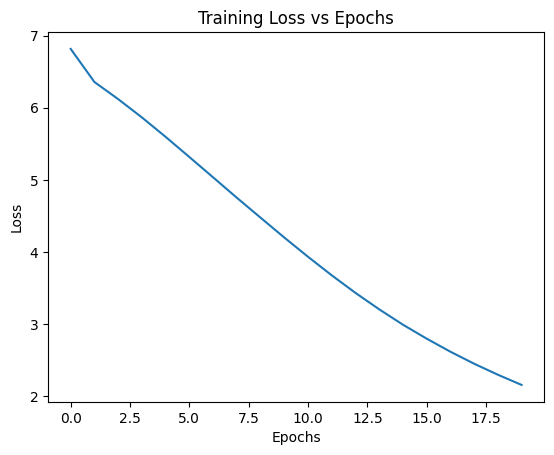

In [ ]:
history = model.fit(X, y, epochs=20, verbose=1)
plt.plot(history.history['loss'])
plt.title("Training Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
def predict_next_word(seed_text, next_words=1):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')

        predicted = model.predict(token_list, verbose=0)
        predicted_word_index = np.argmax(predicted)

        output_word = ""
        for word, index in word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [ ]:
print(predict_next_word("to be or not"))
print(predict_next_word("the king"))
print(predict_next_word("i am"))
print(predict_next_word("what is"))
print(predict_next_word("he shall"))

to be or not to
the king and
i am not
what is the
he shall not
